In [1]:
# 第 1 格｜469 个概念全部准备审核：只读固定输入、设置参数，本格不调用模型。
# 更新后请先重启内核，再从本格开始运行。审核后再按通过图片数挑选，当前不抽 200、不设候选图片下限。
import os
import sys
import json
from pathlib import Path
import lance
import pandas as pd
from IPython.display import display

VISUAL_PROJECT = Path('/yzp/zhaozy/yangzepeng/0905/demiwtg')
root = VISUAL_PROJECT.parent
for path in (VISUAL_PROJECT, root / 'demiflow'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
os.environ['DEMIWTG_DATASETS_ROOT'] = str(root)
from demiflow import data
from demiflow.lance.refs import DatasetRef
from demiflow.lance.storage import schema_hash
from curation.legacy_concept_images import legacy_concept_images_pipeline as image_pipeline

VISUAL_RUN_ID = 't2i_dual_keep469_visual_v3_tp2_20260928'
VISUAL_RUN = root / 'demiwtg/preparation/datasets' / VISUAL_RUN_ID
# 只复用已提交的准备表；旧v2未发出模型请求。None表示重新准备全部输入。
VISUAL_PREPARED_RUN = root / 'demiwtg/preparation/datasets' / 't2i_dual_keep469_visual_v2_20260928'
SCREENING_SOURCE = {
    'uri': 'demiwtg/benchmark/t2i/screening/datasets/results__high_l3_categories_uniform1000_v1_20260927.lance',
    'version': 1,
}
RAW_IMAGE_SOURCE = {'uri': 'demiwtg/collect/datasets/images.lance', 'version': 5}
EXPECTED_CONCEPT_COUNT = 469
concept_rows = data.read_lance(
    str(root / SCREENING_SOURCE['uri']), version=SCREENING_SOURCE['version'],
    columns=['concept', 'taxonomy'], filter="status = 'screened' AND decision = 'keep'",
).take_all()
concept_frame = pd.DataFrame(concept_rows).sort_values('concept').reset_index(drop=True)
assert len(concept_frame) == concept_frame['concept'].nunique() == EXPECTED_CONCEPT_COUNT
visual_raw = lance.dataset(str(root / RAW_IMAGE_SOURCE['uri']), version=RAW_IMAGE_SOURCE['version'])
VISUAL_INPUT = DatasetRef(
    dataset_id=RAW_IMAGE_SOURCE['uri'].removesuffix('.lance'), relative_uri=RAW_IMAGE_SOURCE['uri'],
    lance_version=RAW_IMAGE_SOURCE['version'], schema_name='raw_images', schema_version='v1',
    schema_hash=schema_hash(visual_raw.schema), row_count=visual_raw.count_rows(),
).to_dict()
VISUAL_CONFIG = {
    'concepts': concept_frame['concept'].tolist(),
    'screening_source': SCREENING_SOURCE,  # 随运行冻结；不把筛选理由传给图片模型。
    'image_identity_definitions': {
        'legacy:' + row['concept']: json.dumps(row, ensure_ascii=False) for row in concept_rows
    },  # 概念名与完整 taxonomy 作为上下文，不能代替像素身份核验。
    'image_annotations_ref': None,
    'model': 'qwen3.8-27b', 'base_url': 'http://127.0.0.1:8000/v1',
    'image_review_model': 'gemma-4-31b-it', 'image_review_base_url': 'http://127.0.0.1:8001/v1',
    # 两个节点顺序独占同一组 GPU；按需启动并在节点结束后释放。
    # 服务由模型算子管理，只管理自己启动的进程；端口/GPU 应已空闲。
    'image_primary_service': {
        'model_path': str(root / 'models/Qwen3.8-27B'), 'python': str(root / 'env/bin/python'),
        'gpus': [0, 1], 'tensor_parallel_size': 2, 'data_parallel_size': 1,
        'gpu_memory_utilization': 0.92, 'max_model_len': 32768, 'max_num_seqs': 64,
        'max_num_batched_tokens': 16384, 'limit_mm_per_prompt': {'image': 4},
        'enforce_eager': False, 'startup_timeout_s': 900,
    },
    'image_review_service': {
        'model_path': str(root / 'models/gemma-4-31B-it'), 'python': str(root / 'env/bin/python'),
        'gpus': [0, 1], 'tensor_parallel_size': 2, 'data_parallel_size': 1,
        'gpu_memory_utilization': 0.92, 'max_model_len': 32768, 'max_num_seqs': 32,
        'max_num_batched_tokens': 16384, 'limit_mm_per_prompt': {'image': 4},
        'enforce_eager': False, 'startup_timeout_s': 900,
    },
    # 每次最多4图；先用下列吞吐配置，启动后依据Running/Waiting、KV及新请求速度再调。
    # 客户端在途略高于服务端并行数，用排队吸收读图与返回抖动；不是性能极值保证。
    'image_batch_size': 4, 'image_primary_concurrency': 128, 'image_review_concurrency': 64,
    'image_primary_queue_depth': 16, 'image_review_queue_depth': 8,
    'image_prepare_concurrency': 8, 'image_prepare_queue_depth': 8,
    'image_journal_backend': 'sqlite',
    'max_calls': 5000,  # 每个模型节点的请求批数上限；覆盖本批，不是每概念只审几张。
    'image_filter_output_tokens': 8192, 'timeout_s': 600, 'enable_thinking': False,
    'visual_progress_every': 20,
}
VISUAL_TARGET = 'demiwtg/preparation/images/catalog/datasets/images.lance'
VISUAL_WRITE_MODE = 'merge'  # 公共表新版本保留全表；只有本轮阶段表限定这 469 个概念。
print('本轮使用新的 v3 run：复用旧 v2 固定准备表并重验原图 SHA，保留旧阶段及错误记录；旧 v2 模型调用数为0。')
print(f"已配置 {len(concept_frame)} 个概念；运行名：{VISUAL_RUN_ID}")
print('先全量审核关联图片，再从结果选样。无关联图/无可读图仍保留概念状态，不发空图片请求。')
print('公共目标是累积全表；本轮范围看 knowledge_base / visual_image_meta 阶段及运行记录。')
display(concept_frame)

VISUAL_PIPELINE_CONFIG = image_pipeline.config(
    VISUAL_RUN, VISUAL_INPUT, root, through='export', model_config=VISUAL_CONFIG,
    target_uri=VISUAL_TARGET, write_mode=VISUAL_WRITE_MODE, prepared_run=VISUAL_PREPARED_RUN,
)

# 只读检查服务资源；不会启动或停止任何进程。
import socket
import subprocess
service_rows = []
for role, port in [('Qwen 初审', 8000), ('Gemma 复审', 8001)]:
    with socket.socket() as probe:
        probe.settimeout(1)
        occupied = probe.connect_ex(('127.0.0.1', port)) == 0
    service_rows.append({'stage': role, 'port': port, 'port_state': '已占用' if occupied else '空闲'})
display(pd.DataFrame(service_rows))
try:
    gpu_info = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,utilization.gpu,memory.used,memory.total', '--format=csv'],
        capture_output=True, text=True, timeout=5, check=True,
    )
    print(gpu_info.stdout.strip())
except (OSError, subprocess.SubprocessError) as exc:
    print('GPU 状态未读到，请自行确认：', type(exc).__name__)
print('本配置会顺序部署两模型。执行第 2 格前请释放已有服务占用的端口和 GPU；不会自动接管外部进程。')
print('模型调用日志：', VISUAL_RUN.parent / ('model_calls__' + VISUAL_RUN.name + '.sqlite'))

# 对照实际客户端/服务端配置；不加载权重。
display(pd.DataFrame([
    {'stage': role, 'TP': VISUAL_CONFIG[f'image_{key}_service']['tensor_parallel_size'],
     'DP': VISUAL_CONFIG[f'image_{key}_service']['data_parallel_size'],
     'client_concurrency': VISUAL_CONFIG[f'image_{key}_concurrency'],
     'server_max_num_seqs': VISUAL_CONFIG[f'image_{key}_service']['max_num_seqs'],
     'input_queue': VISUAL_CONFIG[f'image_{key}_queue_depth'],
     'CUDA_Graph': not VISUAL_CONFIG[f'image_{key}_service']['enforce_eager']}
    for key, role in [('primary', 'Qwen 初审'), ('review', 'Gemma 复审')]
]))

print('准备表固定引用：')
display(VISUAL_PIPELINE_CONFIG['model_config']['prepared_inputs'])


本轮使用新的 v3 run：复用旧 v2 固定准备表并重验原图 SHA，保留旧阶段及错误记录；旧 v2 模型调用数为0。
已配置 469 个概念；运行名：t2i_dual_keep469_visual_v3_tp2_20260928
先全量审核关联图片，再从结果选样。无关联图/无可读图仍保留概念状态，不发空图片请求。
公共目标是累积全表；本轮范围看 knowledge_base / visual_image_meta 阶段及运行记录。


,concept,taxonomy
0,88式狙击步枪,[人造物体 / 著名武器 / 著名枪械]
1,Agate Geode,[材料与物质 / 矿物 / 玛瑙]
2,Agate Stone,[材料与物质 / 矿物 / 玛瑙]
3,American Alligator,"[动物 / 爬行动物 / 双孔亚纲动物 / 鳄类动物 / 短吻鳄 / 密西西比短吻鳄, 动物..."
4,Angkor Wat,"[建筑与基础设施 / 宗教建筑 / 印度教寺庙, 组织机构与社会事件 / 组织机构 / 宗教..."
...,...,...
464,齿菌,[真菌与微生物 / 菌类 / 齿菌]
465,齿轮,"[人物与人体 / 劳动者 / 助手 / 下属 / 嵌齿, 人造物体 / 机器 / 组装部件,..."
466,龙灯,[节日与符号 / 中国传统节日 / 元宵节]
467,龙眼,"[场景 / 室内场景 / 商店 / 摊子 / 售货处 / 水果摊, 属性与状态 / 性感, ..."


,stage,port,port_state
0,Qwen 初审,8000,空闲
1,Gemma 复审,8001,空闲


index, utilization.gpu [%], memory.used [MiB], memory.total [MiB]
0, 0 %, 0 MiB, 81559 MiB
1, 0 %, 0 MiB, 81559 MiB
本配置会顺序部署两模型。执行第 2 格前请释放已有服务占用的端口和 GPU；不会自动接管外部进程。
模型调用日志： /yzp/zhaozy/yangzepeng/0905/demiwtg/preparation/datasets/model_calls__t2i_dual_keep469_visual_v3_tp2_20260928.sqlite


,stage,TP,DP,client_concurrency,server_max_num_seqs,input_queue,CUDA_Graph
0,Qwen 初审,2,1,128,64,16,True
1,Gemma 复审,2,1,64,32,8,True


准备表固定引用：


{'run': '/yzp/zhaozy/yangzepeng/0905/demiwtg/preparation/datasets/t2i_dual_keep469_visual_v2_20260928',
 'manifest_sha256': '47b99115f036013432b94ad6061a073c2a7ac47b387a01c32e843ef47f981c90',
 'raw_images_ref': {'content_digest': None,
  'dataset_id': 'demiwtg/collect/datasets/images',
  'lance_version': 5,
  'relative_uri': 'demiwtg/collect/datasets/images.lance',
  'row_count': 2164671,
  'schema_hash': 'sha256:d200a2033310790d5897a781a3aba93af4e364dc1e06751ad54c064c56b7ce0c',
  'schema_name': 'raw_images',
  'schema_version': 'v1',
  'store_id': 'local'},
 'visual_inputs': {'dataset_id': 'demiwtg/preparation/datasets/visual_inputs__t2i_dual_keep469_visual_v2_20260928',
  'store_id': 'local',
  'relative_uri': 'demiwtg/preparation/datasets/visual_inputs__t2i_dual_keep469_visual_v2_20260928.lance',
  'lance_version': 1,
  'schema_name': 'pipeline_stage_rows',
  'schema_version': 'v1',
  'schema_hash': 'sha256:5acf26aba4cff78a51361cd37e96444ed70637784eee0f29552f43a22c423c38',
  'row_co

In [3]:
# 第 2 格｜手工启动：Qwen 初审 → Gemma 独立复审 → 按 SHA 合并到公共图片表。
# 每概念处理全部关联的可读图片；无图概念保留状态。每20条完成行报告新请求/复用及窗口批次吞吐。
# 审核调用由你执行本格启动；不会自动开始出题。
import asyncio
from preparation.articles.operaters.runfiles import run_records
# 保留旧配置供查看；迁移后实际执行须显式选择 curation 下的新运行。
if VISUAL_RUN.parent != root / 'demiwtg/curation/legacy_concept_images/datasets':
    raise ValueError('当前为历史查看配置；执行前将 VISUAL_RUN 改为 curation/legacy_concept_images/datasets 下的新 run，并重跑配置格。')
visual_result = await asyncio.to_thread(
    image_pipeline.run_pipeline, VISUAL_PIPELINE_CONFIG,
)
visual_records = run_records(VISUAL_RUN)
print('本轮概念结果：')
display(visual_records.stage('knowledge_base'))
print('公共图片目标（固定版本；内容仍是累积全表）：')
display(visual_records.publication('results', 'visual'))
print('请运行下一格查看状态分布、审核通过图数与逐概念明细。')


[Visual review] 准备概念图片；指定概念数=469，无图概念保留。


[2026-09-28T11:33:37Z WARN  lance::dataset::write::insert] No existing dataset at /yzp/zhaozy/yangzepeng/0905/demiwtg/preparation/datasets/visual_inputs__t2i_dual_keep469_visual_v3_tp2_20260928.lance, it will be created
[2026-09-28T11:51:22Z WARN  lance::dataset::write::insert] No existing dataset at /yzp/zhaozy/yangzepeng/0905/demiwtg/preparation/datasets/image_requests__t2i_dual_keep469_visual_v3_tp2_20260928.lance, it will be created


[Visual review] 图片请求已准备：1165 批；through=export
[Visual review] 开始初审；并发=128，请求预算=5000


ModelServiceError: Model resource gpu_0 is occupied under /yzp/zhaozy/yangzepeng/0905/_demiflow/local_model_gpus

,stage,rows,version,state
0,visual_inputs,None,None,未提交
1,image_requests,None,None,未提交
2,image_primary,None,None,未提交
3,image_review_inputs,None,None,未提交
4,image_review_responses,None,None,未提交
5,image_relevance,None,None,未提交
6,visual_image_meta,None,None,未提交
7,knowledge_base,None,None,未提交


加载inputs查看索引（逐行读取固定版本，翻页复用缓存）…
inputs查看索引已加载 100 行
inputs查看索引已加载 200 行
inputs查看索引已加载 300 行
inputs查看索引已加载 400 行
候选图来自配置中复用的准备表 @1：demiwtg/preparation/datasets/visual_inputs__t2i_dual_keep469_visual_v2_20260928.lance；不表示本轮审核已完成。
本轮概念 469；结果已提交 0；本轮通过参考图 ≥ 5 的概念 0 个。
未提交的通过图数显示 —；review_pending 表示待定/技术失败，不混入旧发布图片。


,concepts
status,
no_images,102
waiting_for_review,367


已选 469/469 个概念，逐图明细 4195 行（含无图占位）；第 1/105 页，显示 1–40 行。
修改 CONCEPT_FILTER / DETAIL_PAGE / ROWS_PER_PAGE 后重跑本格；detail_frame 保留所选概念的全部行。


concept,status,source_images,readable_images,approved_images
88式狙击步枪,waiting_for_review,4,4,—
Agate Geode,no_images,0,0,—
Agate Stone,no_images,0,0,—
American Alligator,no_images,0,0,—
Angkor Wat,no_images,0,0,—
Araneus Diadematus,no_images,0,0,—
Axe木棒,waiting_for_review,10,9,—
B-17 空中堡垒轰炸机,waiting_for_review,10,10,—
Bar Billiard Table,no_images,0,0,—
Basilica Of Our Lady Of Guadalupe,no_images,0,0,—

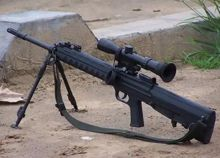
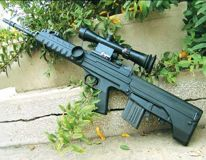
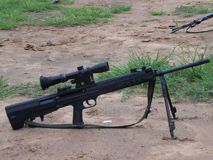
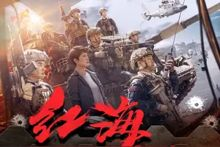
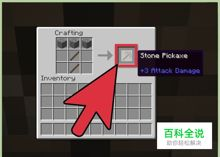
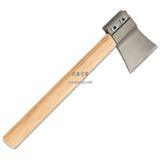
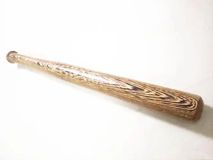
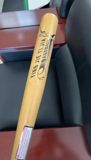
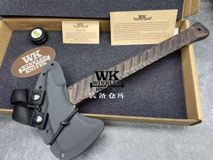
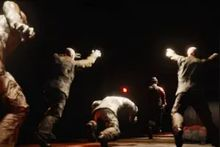
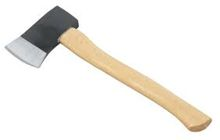
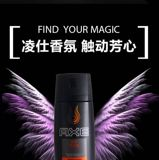
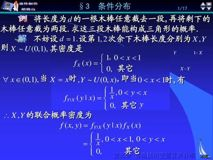
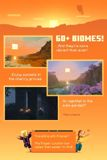
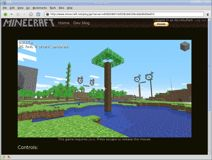
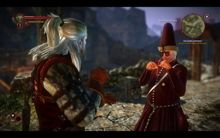
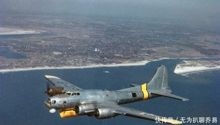
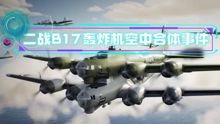
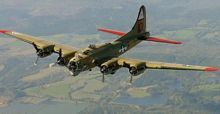
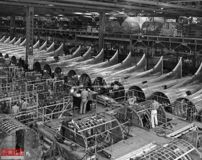
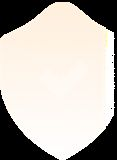
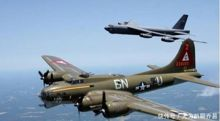
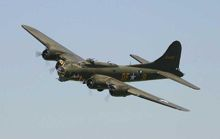

公共目标固定引用（通过材料是否已写公共表，以此提交记录为准）：


None

In [2]:
# 第 3 格｜只读查看全部 469 个概念：先运行第 1 格；更新查看代码后只需重跑本格。
# 改筛选/页码后重跑本格，不会调用模型或写表；未提交阶段的实时进度见运行日志。
CONCEPT_FILTER = None  # None / '' / [] = 全部469；'概念名' = 单选；['概念甲', '概念乙'] = 多选。
DETAIL_PAGE = 1        # 图片明细页码，从1开始；筛选概念时建议回到第1页。
ROWS_PER_PAGE = 40     # 每页图片行数；None = 一次展示所选概念的全部图片（载入较慢）。
THUMBNAIL_SIZE = (220, 160)

from curation.legacy_concept_images.operaters.preview import review_view
view = review_view(root, VISUAL_RUN, VISUAL_CONFIG, VISUAL_PIPELINE_CONFIG, VISUAL_INPUT,
    concept_filter=CONCEPT_FILTER, detail_page=DETAIL_PAGE, rows_per_page=ROWS_PER_PAGE,
    thumbnail_size=THUMBNAIL_SIZE)
review_frame, detail_frame = view["review_frame"], view["detail_frame"]
from IPython.display import HTML
for panel in view["panels"]:
    display(HTML(panel) if isinstance(panel, str) else panel)


In [ ]:
# 第 4 格｜只读运行观察：GPU、模型调用完成/未完成、vLLM 的 Running/Waiting/KV/token 吞吐。
# 第2格占用当前内核时，在另一个内核先运行第1格再运行本格；不要重复启动第2格。
# 本格不会启动模型、重试请求、创建调用库或写目标表。469个概念的图片与审核明细在第3格。
import sqlite3
from datetime import datetime, timezone
print('观察时间：', datetime.now(timezone.utc).isoformat())
try:
    observation = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,utilization.gpu,memory.used,memory.total', '--format=csv'],
        capture_output=True, text=True, timeout=5, check=True,
    )
    print(observation.stdout.strip())
except (OSError, subprocess.SubprocessError) as exc:
    print('GPU 状态未读到：', type(exc).__name__)

call_path = VISUAL_RUN.parent / ('model_calls__' + VISUAL_RUN.name + '.sqlite')
if call_path.is_file():
    with sqlite3.connect(call_path.as_uri() + '?mode=ro', uri=True, timeout=3) as db:
        display(pd.read_sql_query("""
            SELECT coalesce(json_extract(request_json, '$.payload.model'), 'unknown') AS model,
                   count(*) AS reserved,
                   sum(response_json IS NOT NULL) AS saved_responses,
                   sum(response_json IS NULL) AS unanswered,
                   sum(error_json IS NOT NULL) AS transport_errors
            FROM calls GROUP BY model
        """, db))
    print('saved_responses只表示原始响应已保存，格式/审核结论仍看第3格；运行中unanswered含在途，退出后需核查，不能自动重发。')
else:
    print('尚无本轮调用日志：', call_path)

for role in ('primary', 'review'):
    log_path = VISUAL_RUN.parent / '_demiflow' / VISUAL_RUN.name / (role + '_vllm.log')
    print('\n服务日志：', log_path)
    if log_path.is_file():
        with log_path.open('rb') as stream:
            stream.seek(0, 2)
            stream.seek(max(0, stream.tell() - 65536))
            lines = stream.read().decode('utf-8', errors='replace').splitlines()
        print('\n'.join(lines[-12:]))
    else:
        print('本节点尚未启动。')
print('业务进度按批计：最多4图/批。窗口新请求速度与复用速度分开；不要拿含复用总速率对比纯推理吞吐。')
